<a href="https://colab.research.google.com/github/Kado2/EDA_videogames_sales_-_industry_data-1980_2024-/blob/main/Version_en_esp/01_Data_Cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---

<h1 style="text-align: center;font-size: 40px;">Análisis y visualización de ventas de videojuegos.</h1>

---
<center><img src="https://media3.giphy.com/media/v1.Y2lkPTc5MGI3NjExejZwY3lqcGpleWh4ZnBtOTU4amQ5bTdnamZ3eGxpMDMwNmI4ZWp2ayZlcD12MV9pbnRlcm5hbF9naWZfYnlfaWQmY3Q9Zw/H7AsEcCf7K0fCqlB77/giphy.gif"></center>

---

### Introducción del dataset

Una colección exhaustiva de más de 64.000 videojuegos que abarca 40 años de la historia del gaming. El dataset proporciona una visión detallada sobre el rendimiento de diferentes géneros, plataformas y editores a nivel mundial y regional. Este dataset sirve de puente entre los juegos retro clásicos y la era moderna, incluyendo ventas globales, desgloses regionales (Norteamérica, Japón, PAL) y evaluaciones de la crítica. Es perfecto para la predicción de series temporales, análisis de mercado y la creación de motores de recomendación.

El dataset contiene las siguientes variables:

title: Título del juego.

console: Consola para la que se lanzó el juego.

genre: Género del juego.

publisher: Editor (o distribuidor) del juego.

developer: Desarrollador del juego.

critic_score: Puntuación de Metacritic (sobre 10).

total_sales: Ventas globales de copias en millones.

na_sales: Ventas de copias en Norteamérica en millones.

jp_sales: Ventas de copias en Japón en millones.

pal_sales: Ventas de copias en Europa y África en millones.

other_sales: Ventas de copias en el resto del mundo en millones.

release_date: Fecha de lanzamiento del juego.

last_update: Fecha en la que se actualizaron los datos por última vez.

In [1]:
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)

import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns
sns.set_style('whitegrid')


In [5]:
import kagglehub
import os
import shutil

# Download latest version
path = kagglehub.dataset_download("bhushandivekar/video-game-sales-and-industry-data-1980-2024")

print("Path to dataset files:", path)

# Cambio al directorio donde se almaceno el dataset
os.chdir(path)

# Obtengo la ruta para luego listar los archivos, y tomo el segundo del array que es el dataset raw.
source_dir = os.getcwd()
source_file_name = os.listdir(source_dir)[1]
source_path = os.path.join(source_dir, source_file_name)

# Defino la ruta en donde quiero trabajar con el archivo
destination_path = "/content/Video_Games_Sales_Raw.csv"

# Reviso si la copia existe antes de copiarlo en caso de futuras ejecuciones
if not os.path.exists(destination_path):
    # Copio el archivo a la ruta definida
    shutil.copyfile(source_path, destination_path)
    print(f"Archivo copiado desde '{source_path}' hacia '{destination_path}'")
else:
    print(f"El archivo '{destination_path}' ya existe, no se copia.")

Using Colab cache for faster access to the 'video-game-sales-and-industry-data-1980-2024' dataset.
Path to dataset files: /kaggle/input/video-game-sales-and-industry-data-1980-2024
Archivo copiado desde '/kaggle/input/video-game-sales-and-industry-data-1980-2024/Video Games Sales (1980-2024) - Raw.csv' hacia '/content/Video_Games_Sales_Raw.csv'


In [6]:
df = pd.read_csv("/content/Video_Games_Sales_Raw.csv")

In [7]:
print(df.columns)

Index(['img', 'title', 'console', 'genre', 'publisher', 'developer',
       'critic_score', 'total_sales', 'na_sales', 'jp_sales', 'pal_sales',
       'other_sales', 'release_date', 'last_update'],
      dtype='object')


In [8]:
df.head(10)

,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
0,/games/boxart/full_6510540AmericaFrontccc.jpg,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,17-09-2013,NaN
1,/games/boxart/full_5563178AmericaFrontccc.jpg,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,18-11-2014,03-01-2018
2,/games/boxart/827563ccc.jpg,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,28-10-2002,NaN
3,/games/boxart/full_9218923AmericaFrontccc.jpg,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.86,9.06,0.06,5.33,1.42,17-09-2013,NaN
4,/games/boxart/full_4990510AmericaFrontccc.jpg,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,06-11-2015,14-01-2018
5,/games/boxart/full_call-of-duty-modern-warfare...,Call of Duty: Modern Warfare 3,X360,Shooter,Activision,Infinity Ward,8.7,14.82,9.07,0.13,4.29,1.33,08-11-2011,NaN
6,/games/boxart/full_call-of-duty-black-ops_5Ame...,Call of Duty: Black Ops,X360,Shooter,Activision,Treyarch,8.8,14.74,9.76,0.11,3.73,1.14,09-11-2010,NaN
7,/games/boxart/full_4653215AmericaFrontccc.jpg,Red Dead Redemption 2,PS4,Action-Adventure,Rockstar Games,Rockstar Games,9.8,13.94,5.26,0.21,6.21,2.26,26-10-2018,02-11-2018
8,/games/boxart/full_1977964AmericaFrontccc.jpg,Call of Duty: Black Ops II,X360,Shooter,Activision,Treyarch,8.4,13.86,8.27,0.07,4.32,1.20,13-11-2012,07-04-2018
9,/games/boxart/full_4649679AmericaFrontccc.png,Call of Duty: Black Ops II,PS3,Shooter,Activision,Treyarch,8.0,13.80,4.99,0.65,5.88,2.28,13-11-2012,07-04-2018


Para moldear el dataframe, se dropearán la columnas de img, last_update y critics_score ya que no son relevantes para este análisis, también se extraerá sólo el año de release_date

In [9]:
#Dropeo la columna last_update
df = df.drop(columns=['last_update', 'img', 'critic_score'])
print(df.columns)

Index(['title', 'console', 'genre', 'publisher', 'developer', 'total_sales',
       'na_sales', 'jp_sales', 'pal_sales', 'other_sales', 'release_date'],
      dtype='object')


In [ ]:
#Reviso el formato actual de release_date para definir la extracción del año de lanzamiento

df['release_date'].head(4)

Debido a que la columna posee valores NaN, se puede asumir que los videojuegos sin año de lanzamiento pueden ser previos a 1980 (el dataset llega de 1980-2024).

Por lo tanto, primero se va a considerar el tamaño del df y cuantos valores NaN hay en total en el dataset para dropear luego

In [10]:
total_null = df['release_date'].isnull().sum()

total_valores_no_null = df['release_date'].notnull().sum()

print("La cantidad de valores total de todo el dataset es: ", total_null+total_valores_no_null,
      f"\n La cantidad de valores total nulos de release_date es: {total_null}, \n La cantidad de valores no nulos de release_date es: {total_valores_no_null}")

La cantidad de valores total de todo el dataset es:  64016 
 La cantidad de valores total nulos de release_date es: 7051, 
 La cantidad de valores no nulos de release_date es: 56965


Al ser una cantidad muy menor en relación al tamaño de valores no nulos, no habrá demasiada incidencia en el análisis.

In [11]:
df = df.dropna(subset=['release_date'])

A continuación, se limpiara la columna release date extrayendo el año y el mes de lanzamiento:

In [12]:
df['release_date'] = pd.to_datetime(df['release_date'])
df['year'] = df['release_date'].dt.year
df = df.drop(columns=['release_date'])

/tmp/ipykernel_2192/2704487361.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['release_date'] = pd.to_datetime(df['release_date'])


In [13]:
df[df['title'].duplicated() == True].head()

,title,console,genre,publisher,developer,total_sales,na_sales,jp_sales,pal_sales,other_sales,year
1,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,19.39,6.06,0.60,9.71,3.02,2014
3,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,15.86,9.06,0.06,5.33,1.42,2013
9,Call of Duty: Black Ops II,PS3,Shooter,Activision,Treyarch,13.80,4.99,0.65,5.88,2.28,2012
12,Call of Duty: Modern Warfare 3,PS3,Shooter,Activision,Infinity Ward,13.35,5.54,0.49,5.78,1.54,2011
14,Call of Duty: Black Ops,PS3,Shooter,Activision,Treyarch,12.67,6.01,0.48,4.40,1.78,2010


Los juegos tienen valores diferentes por consola.

Se buscará la cantidad de valores nulos en todo el dataset para definir si es necesario dropear más columnas. Se tomará en cuenta que es posible que no haya datos en algunas regiones debido a que algunos juegos son exclusivos de otra región.

In [14]:
df.isnull().sum()

,0
title,0
console,0
genre,0
publisher,0
developer,11
total_sales,38133
na_sales,44345
jp_sales,50277
pal_sales,44189
other_sales,41894


In [15]:
df[df['total_sales'].isnull()].head()

,title,console,genre,publisher,developer,total_sales,na_sales,jp_sales,pal_sales,other_sales,year
18922,God of War,Series,Action,Sony Interactive Entertainment,SIE Santa Monica Studio,NaN,NaN,NaN,NaN,NaN,2005
18923,Warriors,Series,Action,KOEI,Omega Force,NaN,NaN,NaN,NaN,NaN,1997
18924,Devil May Cry,Series,Action,Capcom,Capcom,NaN,NaN,NaN,NaN,NaN,2001
18925,God of War (2018),All,Action,Sony Interactive Entertainment,SIE Santa Monica Studio,NaN,NaN,NaN,NaN,NaN,2018
18926,Dynasty Warriors,Series,Action,KOEI,Omega Force,NaN,NaN,NaN,NaN,NaN,1997


In [16]:
df[~df['total_sales'].isnull()].head()

,title,console,genre,publisher,developer,total_sales,na_sales,jp_sales,pal_sales,other_sales,year
0,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,20.32,6.37,0.99,9.85,3.12,2013
1,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,19.39,6.06,0.60,9.71,3.02,2014
2,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,16.15,8.41,0.47,5.49,1.78,2002
3,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,15.86,9.06,0.06,5.33,1.42,2013
4,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,15.09,6.18,0.41,6.05,2.44,2015


Reviso si la falta de valores tiene relación con el año de lanzamiento

In [17]:
# Agrupo por año y cuento directamente la cantidad de valores nulos en 'total_sales'
null_sales_by_year_alt = df.groupby('year')['total_sales'].apply(lambda x: x.isnull().sum()).reset_index(name='total_sales_null_count')

# Se filtran los años con al menos un valor nulo
null_sales_by_year_alt = null_sales_by_year_alt[null_sales_by_year_alt['total_sales_null_count'] > 0]

# Se ordena los años por la cantidad de valores nulos de forma descendente
null_sales_by_year_alt = null_sales_by_year_alt.sort_values(by='total_sales_null_count', ascending=False)

display(null_sales_by_year_alt.head())

,year,total_sales_null_count
35,2009,2607
40,2014,2266
36,2010,2205
37,2011,2134
46,2020,1424


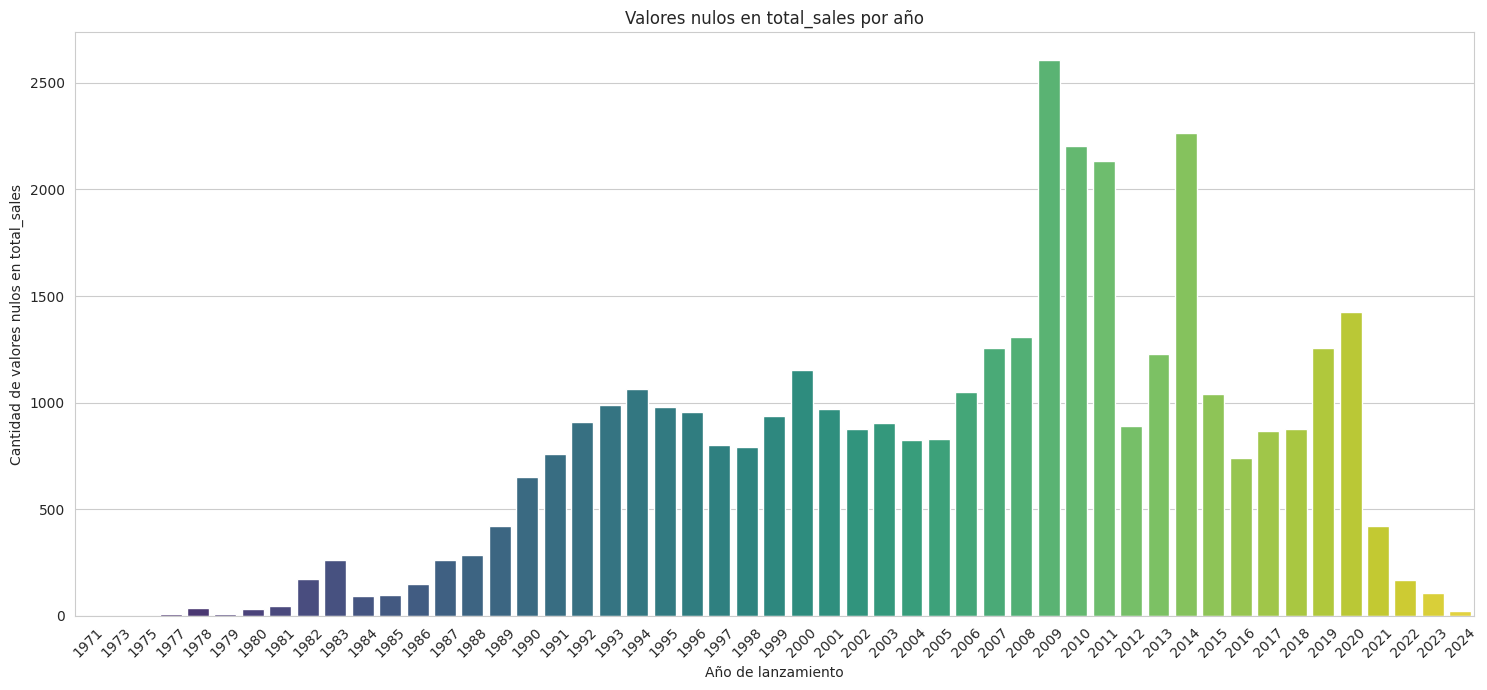

In [18]:
# Creo un gráfico de barras para visualizar mejor
plt.figure(figsize=(15, 7))
sns.barplot(x='year', y='total_sales_null_count', data=null_sales_by_year_alt, palette='viridis', hue='year', legend=False)
plt.title('Valores nulos en total_sales por año')
plt.xlabel('Año de lanzamiento')
plt.ylabel('Cantidad de valores nulos en total_sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Continuo con la cantidad de registros con valores de total_sales no nulos por cada año de lanzamiento. Esto nos dará una idea de la distribución de los datos de ventas válidos a lo largo del tiempo.

In [19]:
# Agrupo por año y cuento directamente la cantidad de valores no nulos en total_sales
non_null_sales_by_year = df.groupby('year')['total_sales'].apply(lambda x: x.notnull().sum()).reset_index(name='total_sales_non_null_count')

# Filtro los años con al menos un valor que no sea nulo
non_null_sales_by_year = non_null_sales_by_year[non_null_sales_by_year['total_sales_non_null_count'] > 0]

# Ordeno los años por la cantidad de valores no nulos de forma descendente
non_null_sales_by_year = non_null_sales_by_year.sort_values(by='total_sales_non_null_count', ascending=False)

display(non_null_sales_by_year.head())

,year,total_sales_non_null_count
35,2009,1753
34,2008,1626
36,2010,1381
33,2007,1268
37,2011,1252


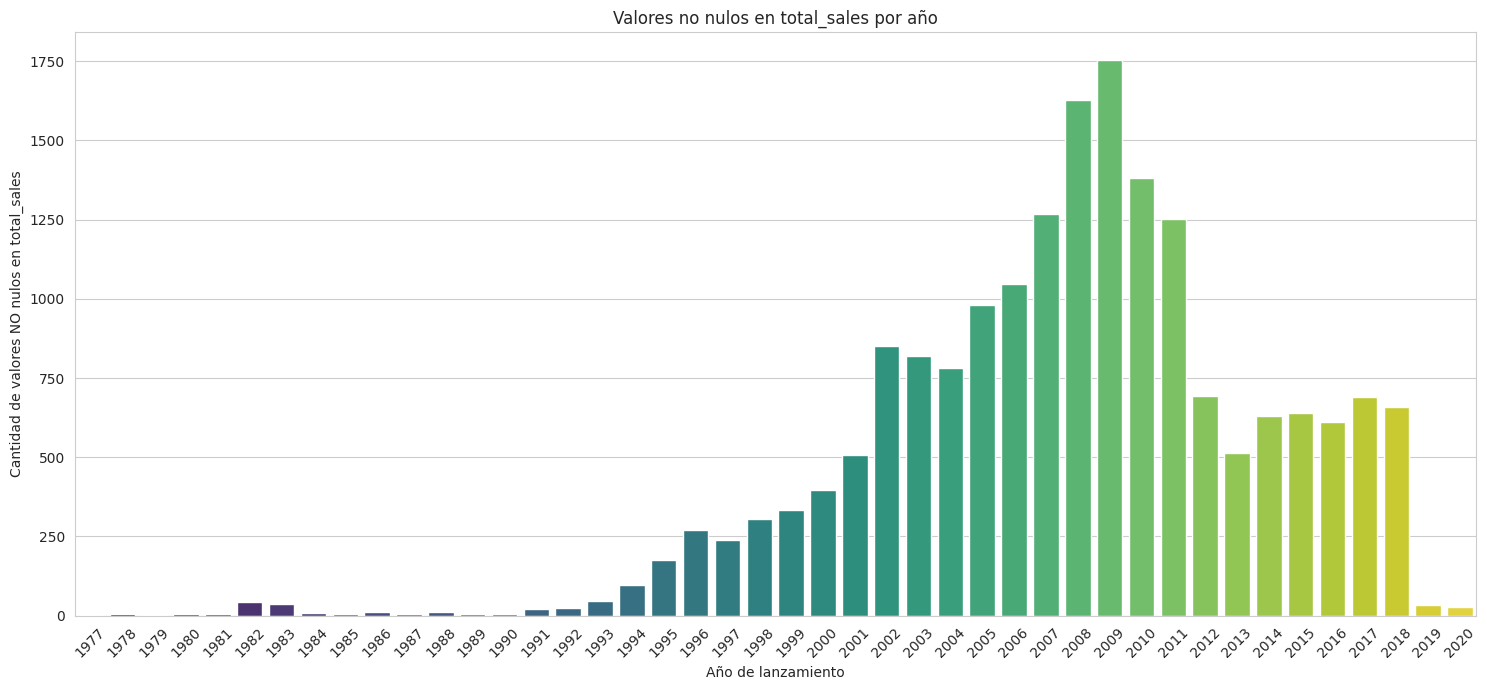

In [20]:
# Creo un gráfico de barras para visualizar mejor
plt.figure(figsize=(15, 7))
sns.barplot(x='year', y='total_sales_non_null_count', data=non_null_sales_by_year, palette='viridis', hue='year', legend=False)
plt.title('Valores no nulos en total_sales por año')
plt.xlabel('Año de lanzamiento')
plt.ylabel('Cantidad de valores NO nulos en total_sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Total de registros: 56965
Porcentaje de datos faltantes en 'total_sales': 66.94%



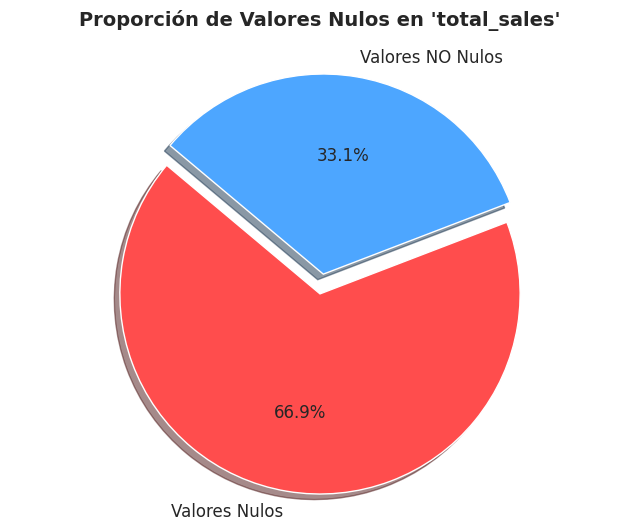

In [21]:
# Calculo los totales directamente sobre la columna del df
total_nulos = df['total_sales'].isnull().sum()
total_no_nulos = df['total_sales'].notnull().sum()
total_registros = total_nulos + total_no_nulos

# Se calcula e imprime el porcentaje
porcentaje_nulos = (total_nulos / total_registros) * 100
print(f"Total de registros: {total_registros}")
print(f"Porcentaje de datos faltantes en 'total_sales': {porcentaje_nulos:.2f}%\n")

# Realizo un pie chart para visualizar la incidencia
labels = ['Valores Nulos', 'Valores NO Nulos']
sizes = [total_nulos, total_no_nulos]
colores = ['#ff4d4d', '#4da6ff'] # Rojo para nulos y azul para válidos
explode = (0.1, 0)  # Separa levemente la primera porción (Nulos) para darle énfasis

plt.figure(figsize=(8, 6))
plt.pie(sizes,
        explode=explode,
        labels=labels,
        colors=colores,
        autopct='%1.1f%%', # Formatea el porcentaje a un decimal
        shadow=True,
        startangle=140, # Gira el gráfico para que quede estéticamente mejor posicionado
        textprops={'fontsize': 12}) # Aumenta un poco el tamaño de la fuente

plt.title("Proporción de Valores Nulos en 'total_sales'", fontsize=14, fontweight='bold', pad=20)
plt.axis('equal') # Asegura que las proporciones formen un círculo perfecto

plt.show()

Conclusión respecto a la calidad de datos sobre ventas del dataset:

El volumen de la variable total_sales carece de valores suficientes para extraer conclusiones apropiadas y representativas en cuanto a las ventas generales, ya que presenta un 66.9% de valores nulos.

Por lo tanto, se conservará la variable, pero se dejará constancia de este déficit crítico en las conclusiones finales de cualquier análisis relacionado a las ventas.

In [22]:
df.columns

Index(['title', 'console', 'genre', 'publisher', 'developer', 'total_sales',
       'na_sales', 'jp_sales', 'pal_sales', 'other_sales', 'year'],
      dtype='object')

El siguiente paso es para almacenar dos versiones a utilizar, un csv para almacenar la limpieza y trabajar sobre él, incluyendo las columnas de ventas, y otro csv sin esas columnas, para garantizar una mayor precisión a las preguntas relacionadas al panorama de la industria

In [23]:
# Importo la librería para conectar con Google Drive
# from google.colab import drive

# Conecto mi drive al colab para almacenar los csv limpios
# drive.mount('/content/drive')

# CSV 1: Completo para el panorama de la industria
df_industry = df.copy()

# CSV 2: Para el análisis de ventas (dropeando los nulos de total_sales)
df_sales = df.dropna(subset=['total_sales']).copy()

# Defino la ubicación de los archivos
# ruta_industry = '/content/drive/MyDrive/Proyecto_videogames_industry/industry_landscape_cleaned_esp.csv'
# ruta_sales = '/content/drive/MyDrive/Proyecto_videogames_industry/sales_analysis_cleaned_esp.csv'

# Exporto los df como csv con codificación UTF-8 para evitar problemas con caracteres especiales
# index=False para evitar que Pandas guarde la columna de índices en el archivo
# df_industry.to_csv(ruta_industry, index=False, encoding='utf-8')
# df_sales.to_csv(ruta_sales, index=False, encoding='utf-8')

Comento las líneas de código para futuras ejecuciones ya que no es necesario volver a subir los archivos

In [24]:
df_sales.shape

(18832, 11)

In [25]:
df_industry.shape

(56965, 11)